In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

Tnu = [read_parameters("/data1/DATA_Duplat/Brut/Fractal/Fr1n{}".format(nb))[2] for nb in range(1,15)]
Tfolderpath = ["/data1/DATA_Duplat/Brut/Fractal/Fr1n{}".format(nb) for nb in np.arange(1,15)]
params= read_parameters(Tfolderpath[0])
L1 = params[0]
L2 = params[1]

In [2]:
n = 100
data = read_gz_with_pandas_nrows("/data1/DATA_Duplat/Brut/Test/Te56n2/fractalbox.gz", nrows = int(n))
print(data)

# data = read_gz_with_pandas_nrows("/data1/DATA_Duplat/Brut/Test/Te56n2/Avalanche_outputB.gz", nrows = int(n))
# print(data)

# y = data[6]
# n = y[-1]
# print(y)
# x = np.array([1,2,4,8,16,32,64,128,256])
# log_x = np.log2(x[:n][y[:n]!=0])
# log_y = np.log2(y[:n][y[:n]!=0])
# sum_x = np.sum(log_x)
# sum_y = np.sum(log_y)
# sum_xy = np.sum(log_x*log_y)
# sum_x2 = np.sum(log_x**2)

# b = (n*sum_xy - sum_x*sum_y)/(n*sum_x2 - sum_x**2)
# print(log_x)
# print(log_y)
# print(sum_x)
# print(sum_y)
# print(sum_xy)
# print(sum_x2)
# print(b)



            

[[   3    2    1    0    0    0    0    0    0    1]
 [ 194   57   22   12    6    2    1    0    0    5]
 [2167  577  163   54   17    6    2    1    0    6]
 [   4    2    1    0    0    0    0    0    0    1]
 [2280  609  167   48   17    6    4    1    0    6]
 [   1    1    0    0    0    0    0    0    0    0]
 [  10    5    2    2    2    1    0    0    0    4]
 [ 712  198   60   19    6    2    1    0    0    5]
 [   1    1    0    0    0    0    0    0    0    0]
 [   1    1    0    0    0    0    0    0    0    0]
 [4240 1127  313   94   34   14    6    3    0    7]
 [   2    1    0    0    0    0    0    0    0    0]
 [   2    1    0    0    0    0    0    0    0    0]
 [   2    1    0    0    0    0    0    0    0    0]
 [2490  665  184   53   18    7    3    1    0    6]
 [ 168   53   16    6    2    2    2    1    0    6]
 [   3    2    1    0    0    0    0    0    0    1]
 [   1    1    0    0    0    0    0    0    0    0]
 [2925  788  224   68   23    9    5    3    0

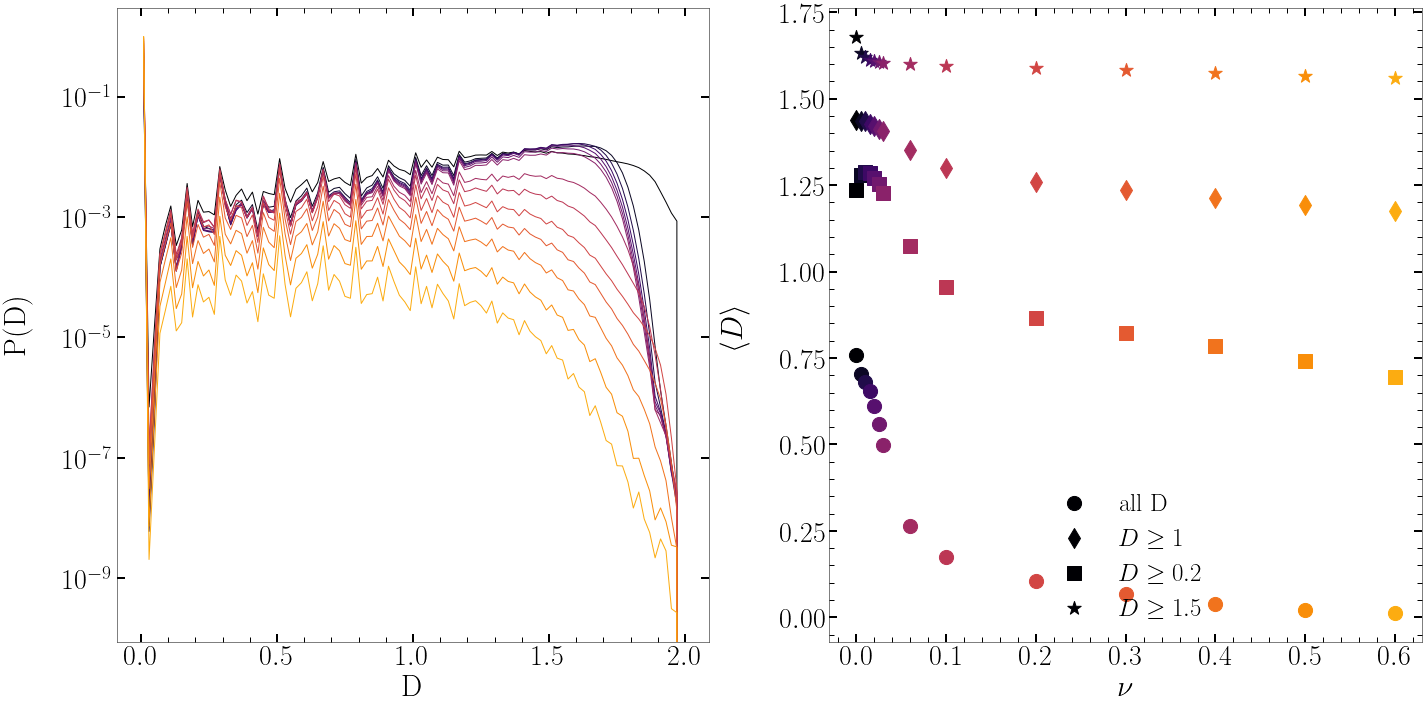

In [3]:

data = [np.loadtxt("/data1/DATA_Duplat/Brut/Fractal/Fr1n{}/stat_histofractal.txt".format(nb)) for nb in range(1,15)]
bins = np.linspace(0,2,101)
bins_centers = (bins[1:] + bins[:-1])/2

NCURVES = len(data) + 2
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (20,10))
for i, histo in enumerate(data):

    mean = np.sum(histo * bins_centers)/np.sum(histo)
    mask = bins_centers >= 1
    histo_cutoff = histo[mask]
    bins_centers_cutoff = bins_centers[mask]
    
    mask2 = bins_centers >= 0.2
    histo_cutoff2 = histo[mask2]
    bins_centers_cutoff2 = bins_centers[mask2]
    
    mask3 = bins_centers >= 1.5
    histo_cutoff3 = histo[mask3]
    bins_centers_cutoff3 = bins_centers[mask3]
    
    mean_cutoff = np.sum(histo_cutoff * bins_centers_cutoff)/np.sum(histo_cutoff)
    mean_cutoff2 = np.sum(histo_cutoff2 * bins_centers_cutoff2)/np.sum(histo_cutoff2)
    mean_cutoff3 = np.sum(histo_cutoff3 * bins_centers_cutoff3)/np.sum(histo_cutoff3)
    ax1.plot(bins_centers, histo/np.sum(histo), color = colors[i], label = i)
    if i == 0:
        ax2.scatter(Tnu[i], mean, color = colors[i], s = 200, label = 'all D')
        ax2.scatter(Tnu[i], mean_cutoff, color = colors[i], marker = 'd', s = 200, label = r'$D \geq 1$')
        ax2.scatter(Tnu[i], mean_cutoff2, color = colors[i], marker = 's', s = 200, label = r'$D \geq 0.2$')
        ax2.scatter(Tnu[i], mean_cutoff3, color = colors[i], marker = '*', s = 200, label = r'$D \geq 1.5$')
    else: 
        ax2.scatter(Tnu[i], mean, color = colors[i], s = 200)
        ax2.scatter(Tnu[i], mean_cutoff, color = colors[i], marker = 'd', s = 200)
        ax2.scatter(Tnu[i], mean_cutoff2, color = colors[i], marker = 's', s = 200)
        ax2.scatter(Tnu[i], mean_cutoff3, color = colors[i], marker = '*', s = 200)
ax1.set_yscale('log')
para_fig(ax1, 'D', 'P(D)')
para_fig(ax2, r'$\nu$', r'$\langle D \rangle$')
plt.legend(fontsize = 25)
plt.tight_layout()
plt.show()    



## Apply a cut-off on avalanche size

In [2]:
def process_fractal(folder, csize, nbmaxline, smin, smax):
    
    histo = np.zeros(100)
    nbline = 0
    for chunk in chunked_file_reader(f'{folder}/fractalbox.gz', chunksize=csize,):
        
        nmax = np.array(chunk.iloc[:, -1])
        y = np.array(chunk.iloc[:, :-1])
        s = np.array(chunk.iloc[:, 0])
        
        print(np.shape(s))
        print(np.shape(y))
        mask = (s > smin) & (s[:] < smax)
        y_filtered = y[mask]
        nmax_filtered = nmax[mask]
        
        for line, nmax_line in zip(y_filtered, nmax_filtered):
            if nmax_line > 2:
                
                log_x = np.log2(x[:nmax_line])
                log_y = np.log2(line[:nmax_line])
                sum_x = np.sum(log_x)
                sum_y = np.sum(log_y)
                sum_xy = np.sum(log_x*log_y)
                sum_x2 = np.sum(log_x**2)

                b = (nmax_line*sum_xy - sum_x*sum_y)/(nmax_line*sum_x2 - sum_x**2)
                histo[int(-b * 50)] +=1
            else : 
                histo[0] +=1
            
        nbline += len(chunk)
        
        if nbline >= nbmaxline : break
    
    return histo
    
    
def process_fractal2(folder, csize, nbmaxline, smin, smax):
    
    histo = np.zeros(100)
    bins = np.linspace(0,2,101)
    nbline = 0
    for chunk in chunked_file_reader(f'{folder}/Avalanche_outputB.gz', chunksize=csize, usecols=[1,6]):
        nbline += len(chunk)
        
        s = np.array(chunk.iloc[:, 0])
        slope = np.array(chunk.iloc[:, 1])
        
        mask = (s > smin) & (s[:] < smax)
        s_filtered = s[mask]
        slope_filtered = slope[mask]
        
        
        histo_temp= np.histogram(-slope_filtered, bins = bins)[0]
        
        histo += histo_temp
        
        if nbline >= nbmaxline : break
    
    return histo

In [5]:
Tnu = [read_parameters("/data1/DATA_Duplat/Brut/Fractal/Fr1n{}".format(nb))[2] for nb in range(1,15)]
Tfolderpath = ["/data1/DATA_Duplat/Brut/Fractal/Fr1n{}".format(nb) for nb in np.arange(1,15)]
NCURVES = len(Tfolderpath)
smin = 5e2
smax = 1e3
x = np.array([1,2,4,8,16,32,64,128,256])

bins = np.linspace(0,2,101)
bins_centers = (bins[1:] + bins[:-1])/2

histo = np.zeros(100)
csize= 1e6
Tnbmaxline = [1e8] * NCURVES
Tnbmaxline[0] = 2e7

# results = Parallel(n_jobs=-1)(delayed(process_fractal)(folder, csize, nbmaxline, smin, smax) for folder in Tfolderpath)

results = Parallel(n_jobs=-1)(delayed(process_fractal2)(folder, csize, maxline, smin, smax) for (folder, maxline) in zip(Tfolderpath, Tnbmaxline))


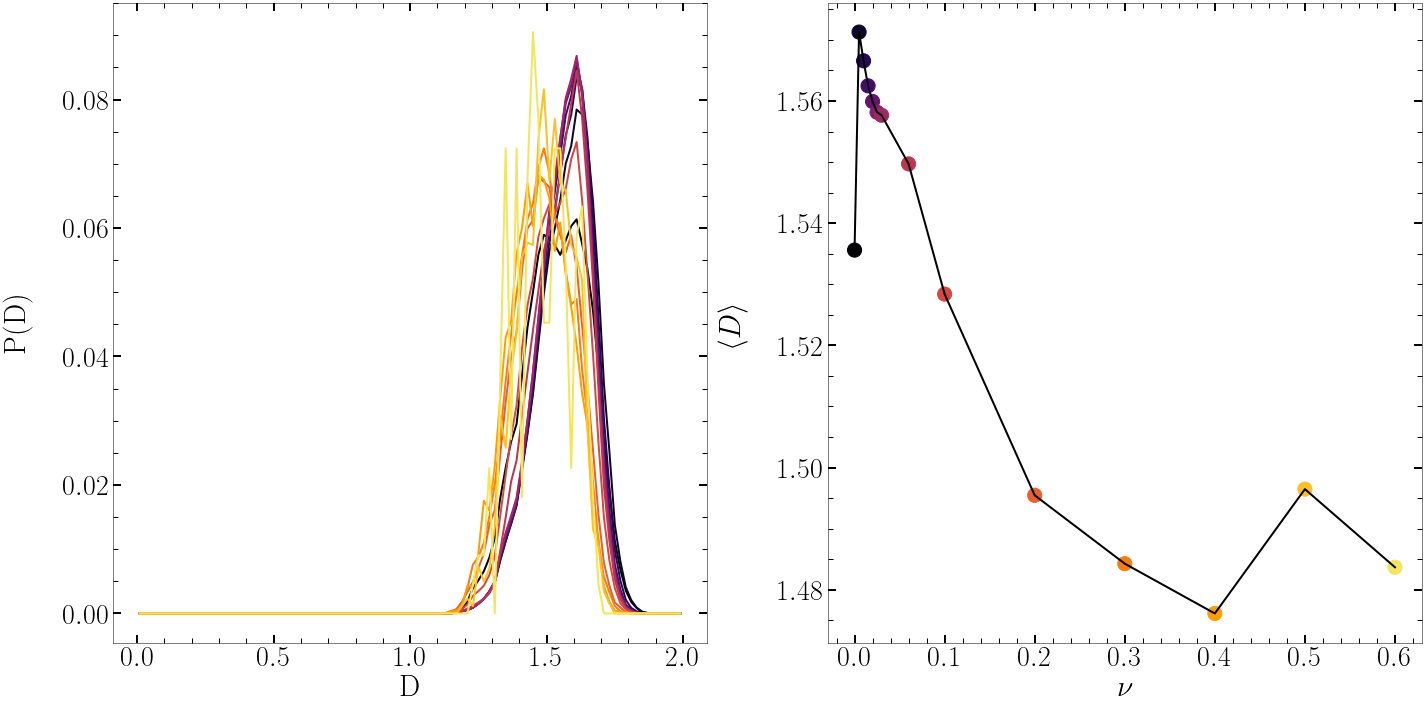

In [6]:
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (20,10))
Tmean =[]
for i, histo in enumerate(results):

    mean = np.sum(histo * bins_centers)/np.sum(histo)
    Tmean.append(mean)
    ax1.plot(bins_centers, histo/np.sum(histo), color = colors[i], lw = 2)
    

ax2.plot(Tnu, Tmean, c = 'k', lw = 2, )
ax2.scatter(Tnu, Tmean, color = colors, s = 200)
    
para_fig(ax1, 'D', 'P(D)')
para_fig(ax2, r'$\nu$', r'$\langle D \rangle$')
plt.tight_layout()
plt.show()

##  Filtre by chi2

In [2]:
def re_calc_chi2(x, y, nmax):
    

    # islice = slice(0,nmax)
    # f_x = x[islice]
    # f_y = y[islice]
    f_x = [x[0:n] for n in nmax]
    f_y = [line[0:n] for n, line in zip(nmax, y)]
    chi2 = np.zeros(len(nmax))
    

    for i, (s_box, count) in enumerate(zip(f_x, f_y)):
        n = nmax[i]
        if n < 3:
            continue
        log_x = np.log2(s_box) 
        count[count == 0] = 1
        log_y = np.log2(count)
        
        sum_x = np.sum(log_x)
        sum_y = np.sum(log_y)
        sum_xy = np.sum(log_x*log_y)
        sum_x2 = np.sum(log_x**2)

        b = (n*sum_xy - sum_x*sum_y)/(n*sum_x2 - sum_x**2)
        a = (sum_y-b*sum_x)/n

        S12 = np.sum((log_y-(a+b*log_x))**2)
        S22 = np.sum((log_x-sum_x/n)**2)
        
        chi2[i] = np.sqrt((1.0/(n-2)) * S12/S22)
        
    
    return chi2

def process_fractal(folder, csize, nbmaxline, chi2_max = 1, nbins = 50):
    nbline = 0
    L1 = read_parameters(folder)[0]
    L2 = read_parameters(folder)[1]
    
    bins = np.linspace(0,2,nbins + 1)
    histo_slope = np.zeros(nbins)
    
    logbins = np.logspace(np.log10(1), np.log10(L1 * L2 +1), nbins +1)
    slope_per_size = np.zeros((nbins, 2)) #sum, count
    
    for chunk, chunk2 in zip(chunked_file_reader(f'{folder}/Avalanche_outputB.gz', chunksize=csize, usecols=[1,6, 7]), 
                     chunked_file_reader(f'{folder}/fractalbox.gz', chunksize=csize)):
        nbline += csize
        
        size = np.array(chunk.iloc[:, 0])
        slope = -np.array(chunk.iloc[:, 1])
        fractalbox = np.array(chunk2.iloc[:, :-1])
        nmax = np.array(chunk2.iloc[:, -1])
        
        x = np.array([1,2,4,8,16,32,64,128,256])
        chi2 = re_calc_chi2(x, fractalbox, nmax)
        
        mask = chi2 < chi2_max
        f_size = size[mask]
        f_slope = slope[mask]
        f_fractalbox = fractalbox[mask]
        f_chi2 = chi2[mask]
        
        slope_per_size += np.array([[np.sum(f_slope[(smin<= f_size) & (f_size< smax)]), len(f_slope[(smin<= f_size) &  (f_size< smax)])]
                                    for smin, smax in zip(logbins[:-1], logbins[1:])])
        
        histo_slope += np.histogram(f_slope, bins = bins)[0]
        
        if nbline >= nbmaxline : break
        
        
    mean_slope_per_size = slope_per_size[:, 0]/slope_per_size[:, 1]
    return histo_slope, mean_slope_per_size, 

In [6]:
NCURVES = len(Tfolderpath)
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]
csize = 1e5

nbmaxline = 1e5
nbline = 0
chi2_max = 0.1
nbins = 20
        
results = np.array(Parallel(n_jobs=-1)(delayed(process_fractal)(folder, csize, nbmaxline, chi2_max, nbins = nbins) for folder in Tfolderpath))


In [7]:
print(np.shape(results))

Thisto_slope = np.zeros((len(Tfolderpath), nbins))
Tmean_slope_per_size = np.zeros((len(Tfolderpath), nbins))

for i, result in enumerate(results):
    Thisto_slope[i], Tmean_slope_per_size[i]= result



(14, 2, 20)


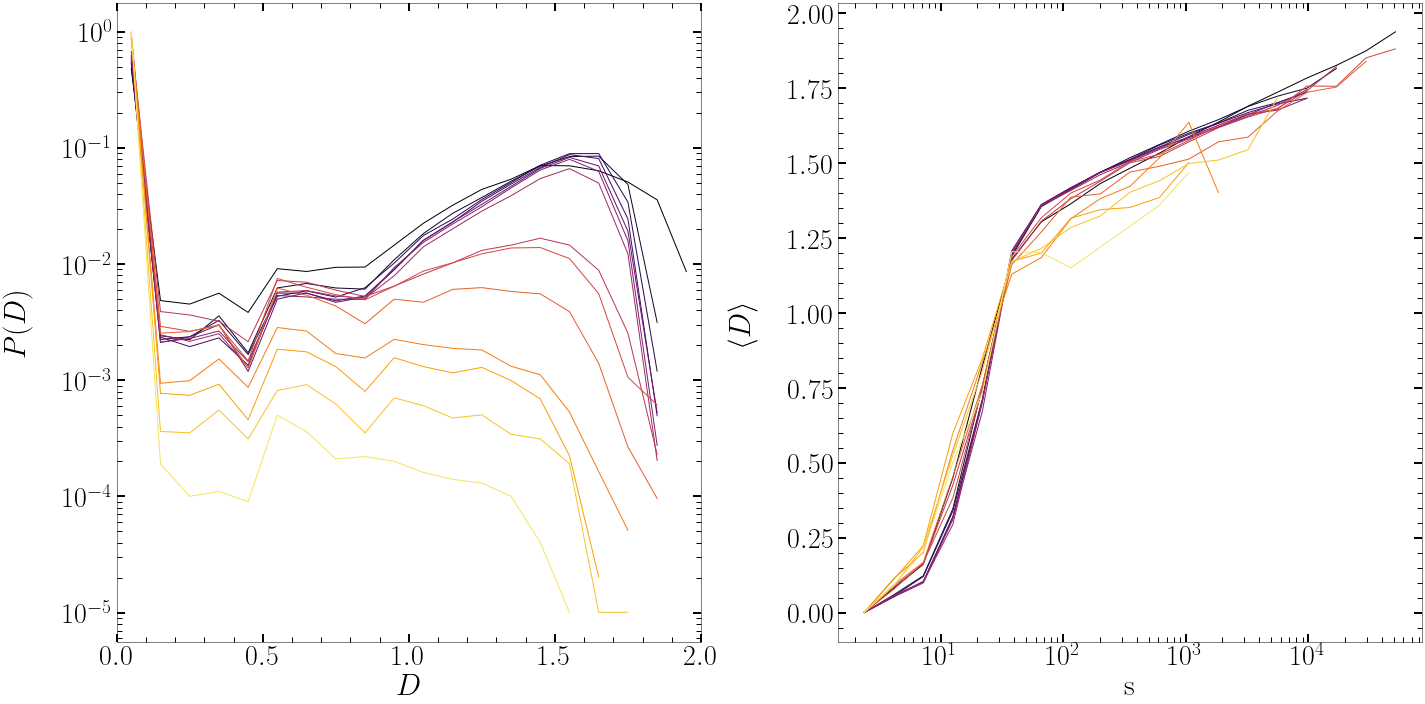

In [8]:
bins = np.linspace(0,2,nbins + 1)
bins_centers = (bins[1:] + bins[:-1])/2

logbins = np.logspace(np.log10(1), np.log10(L1 * L2 +1), nbins + 1)
log_bins_centers = (logbins[1:] + logbins[:-1])/2

fig, (ax1, ax2) = plt.subplots(1,2,figsize =(20,10))
for i, (histo, data) in enumerate(zip(Thisto_slope, Tmean_slope_per_size)):
    mask = histo > 0
    f_histo = histo[mask]
    f_bins_centers = bins_centers[mask] 
    ax1.plot(f_bins_centers, f_histo/np.sum(f_histo), color = colors[i])
    
    mask2 = data > 0
    f_data = data[mask2]
    f_log_bins_centers = log_bins_centers[mask2]
    ax2.plot(f_log_bins_centers, f_data, color = colors[i])
para_fig(ax1, r"$D$", r"$P(D)$")
ax1.set_yscale('log')
ax1.set_xlim(0,2)

para_fig(ax2, "s", r"$\langle D \rangle$")
ax2.set_xscale('log')

plt.tight_layout()
plt.show()
    


In [5]:
nbline = 1000
x = np.array([1,2,4,8,16,32,64,128,256])

fractalbox = read_gz_with_pandas_nrows("/data1/DATA_Duplat/Brut/Fractal/Fr1n1/fractalbox.gz", nbline)
slope = read_gz_with_pandas_nrows("/data1/DATA_Duplat/Brut/Fractal/Fr1n1/Avalanche_outputB.gz", nbline, cols = [6])
chi2 = re_calc_chi2(x, fractalbox[:, :-1], fractalbox[:,-1])

print(fractalbox[0])
print(np.shape(fractalbox))
print(np.shape(chi2))
mask = chi2 < 0.05
f_chi2 = chi2[mask]
f_slope = slope[mask]
f_fractalbox = fractalbox[mask]

mask2 = f_fractalbox[:,1] > 1000
f2_fractalbox = f_fractalbox[mask2]
f2_chi2 = f_chi2[mask2]
f2_slope = f_slope[mask2]
print(f2_fractalbox[:10])

[4 3 2 1 0 0 0 0 0 2]
(1000, 10)
(1000,)
[[ 8253  2160   588   168    51    18     7     4     0     7]
 [11800  3046   806   218    63    18     6     3     0     7]
 [ 5186  1375   377   111    35    12     5     2     0     7]
 [48767 12346  3147   815   213    58    16     4     0     7]
 [27601  7057  1830   490   135    40    13     4     0     7]
 [12129  3146   831   233    71    22     8     3     0     7]
 [ 9631  2484   644   171    48    15     4     1     0     6]
 [50155 12711  3239   832   218    59    16     4     0     7]
 [ 5545  1459   394   110    36    12     4     1     0     6]
 [26926  6862  1767   464   125    36    12     4     0     7]]


In [ ]:
y = f2_fractalbox[0, :-1]
b = f2_slope[0]
x = np.array([1,2,4,8,16,32,64,128,256])
fig, ax = plt.subplots(figsize = (10,10))
ax.scatter(x[:], y, s = 100)
ax.plot(x[:6], powerlaw(x[:6], y[0], b))
para_fig(ax, "L_box", "nbox", type = 'loglog')
plt.show()
    
    

In [5]:
def fractal_algo(folder, L1, L2, nbmaxline = 10, h = 2, w = 5, sys_fraction = 100, plt_switch = 1, skiprow = 0):
    scales = np.array([1,2,4,8,16,32,64,128,256])
    data = np.zeros((nbmaxline, (L1*L2)), dtype = int)
    x, y = np.zeros_like(data), np.zeros_like(data)
    Tfractalbox = np.zeros((nbmaxline, len(scales)))
    TDslope =  np.zeros(nbmaxline)
    TRsquared = np.zeros(nbmaxline)
    TNava = np.zeros(nbmaxline, dtype = int)
    
    if plt_switch:
        fig, axis = plt.subplots(h*2,w,figsize = (w*10,h*10 * 2))
        
    with open("{}/shape_outputB10.txt".format(folder), "r") as f:
        l = 0
        for _ in range(skiprow):
            next(f)
        for line in f:
            if line.startswith("#"): 
                continue
            line_np = np.array(list(map(int, line.split()[3:])), dtype = int)
            Nava = int(line.split()[0])
            if len(line_np) > ((L1 * L2)/sys_fraction):
                
                data[l, :len(line_np)] = line_np
                
                
                x, y = np.unravel_index(line_np, (L1, L2))
            
                points = np.stack((x, y), axis = 1)   
                result = box_counting(points, scales, method="original", return_boxes=True)
                Tfractalbox[l] = result["boxes"][:,1]
                TDslope[l] = result["fd"]
                TRsquared[l] = result["r_squared"]
                TNava[l] = Nava - 1
                
                if plt_switch:
                    NCURVES = len(x)
                    colors = plt.cm.get_cmap('inferno')(1 - np.linspace(0, 1, NCURVES))
                    i,j = np.unravel_index(l, (h,w))
                    axis[i*2][j].scatter(x, y, c = colors)
                    axis[i*2][j].set_xlim(-1,L1)
                    axis[i*2][j].set_ylim(-1,L2)
                    
                    axis[(i*2)+1][j].scatter(scales, Tfractalbox[l], c = "C0")
                    axis[(i*2)+1][j].plot(scales, powerlaw(scales, Tfractalbox[l, 0], -TDslope[l]), c = "C0", label = "slope = {}".format(-np.round(TDslope[l],2)))
                    para_fig(axis[(i*2)+1][j], r"$\epsilon$", r"$n \epsilon$", type = "loglog")
                    axis[(i*2)+1][j].legend(fontsize = 25)
                
                l += 1
                if l == nbmaxline:
                    break
                
    if plt_switch:
        plt.tight_layout()
        
        plt.savefig("Avalanche_propagation.pdf")
        plt.show()
    return Tfractalbox, TDslope, TRsquared, TNava
    
    
    

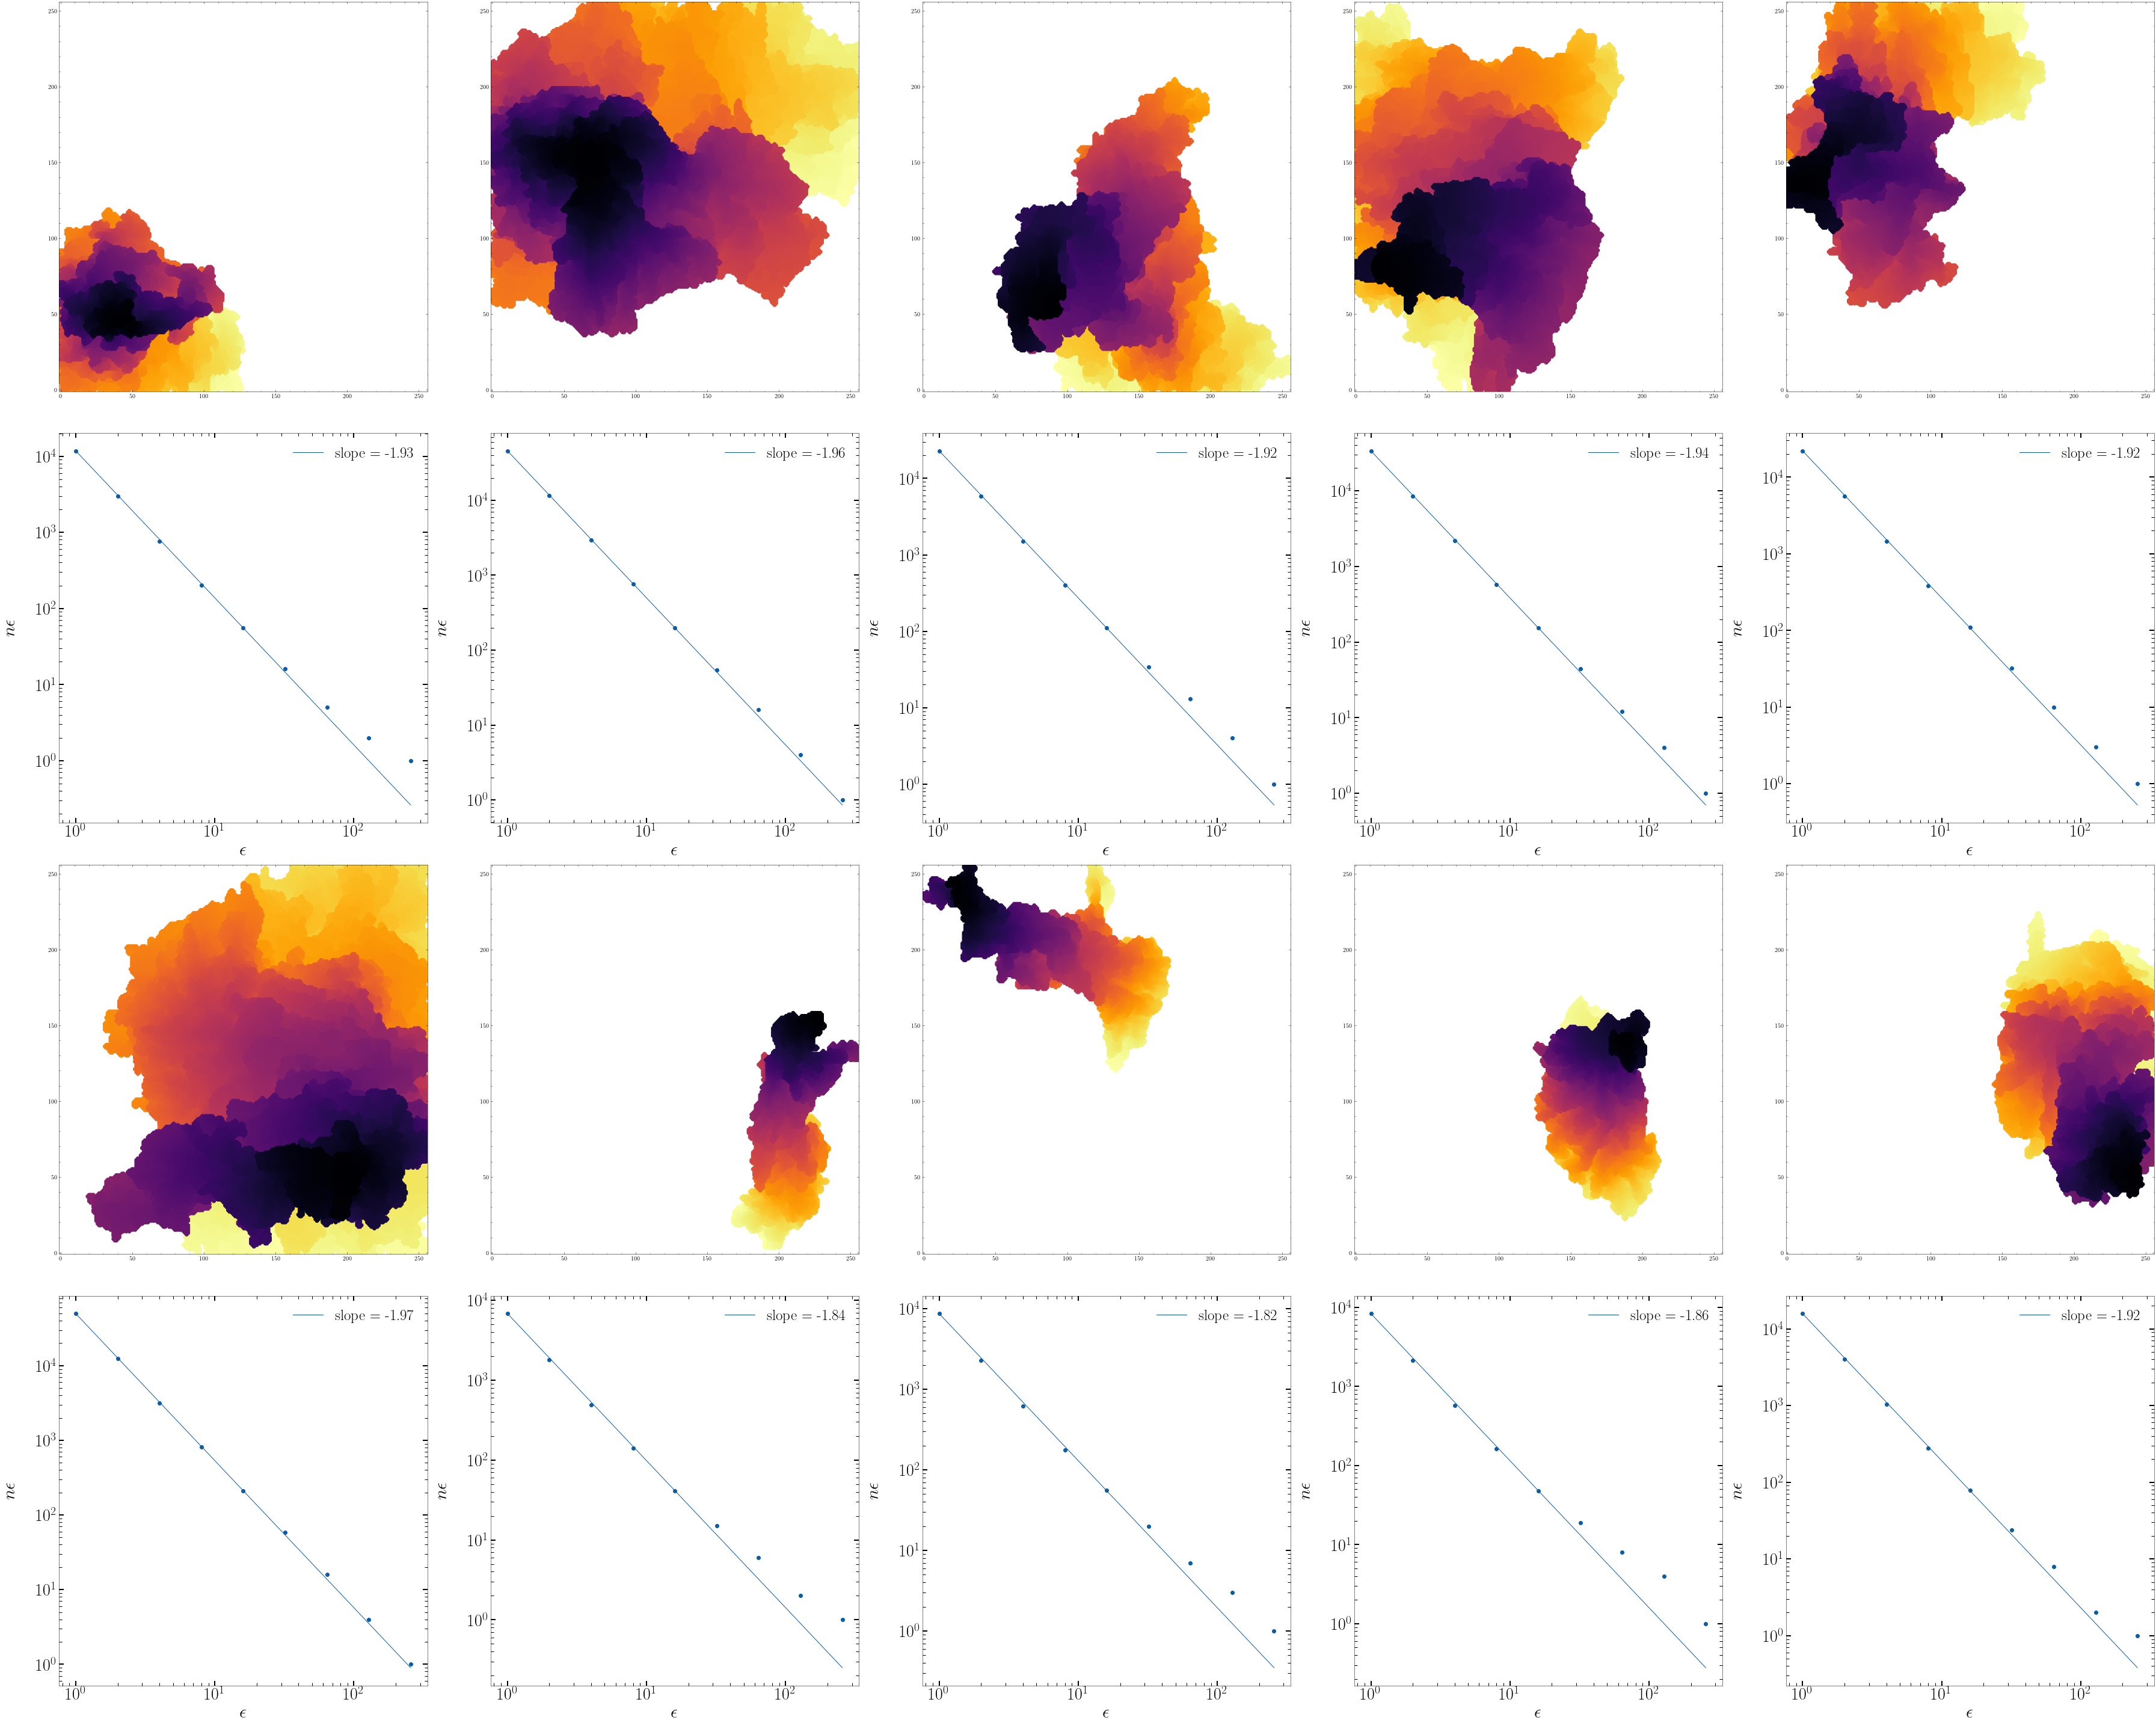

' fig, ax = plt.subplots(figsize = (10,10))\nax.scatter(x, fractalbox[:-1], label = "fractal box")\nax.plot(x, powerlaw(x, f_fct_fractalbox[0], -f_fct_Dslope), label = \'fct\')\nax.plot(x, powerlaw(x, f_fct_fractalbox[0], Dslope), label = \'C\')\npara_fig(ax, "L_box", "nbox", type = \'loglog\')\nplt.legend(fontsize = 20)\nplt.show() '

In [14]:
L1 = 256
L2 = 256
x = np.array([1,2,4,8,16,32,64,128,256])
# fractal_algo("/data1/DATA_Duplat/Brut/Fractal/Fr1n1", L1, L2, nbmaxline = 1)

folder = "/data1/DATA_Duplat/Brut/PDF/PD5n1"

""" ava = read_gz_with_pandas_nrows("{}/Avalanche_outputB.gz".format(folder), 100)
Nava = 92
ava = ava[Nava]
s = ava[1]
Dslope = ava[6]

fractalbox = read_gz_with_pandas_nrows("{}/fractalbox.gz".format(folder), 100)
fractalbox = fractalbox[Nava]
chi2 = re_calc_chi2(x, [fractalbox[:-1]], [fractalbox[-1]]) """

fct_fractalbox, fct_Dslope, fct_chi2, fct_Tnava = fractal_algo(folder, L1, L2, nbmaxline = 10, sys_fraction = 10, skiprow = 0)

""" print("count box: ", fractalbox)
print("s :",s)
print("slope: ", -Dslope)
print("chi2: ", chi2)

print("fct_count box: ", fct_fractalbox[0])
print("fct_slope: ", -fct_Dslope)
print("fct_chi2: ", fct_chi2)
print("Tnava: ", Tnava) """

""" id = np.argwhere(fct_Tnava == Nava)[0][0]
f_fct_fractalbox = fct_fractalbox[id]
f_fct_Dslope = fct_Dslope[id]
f_fct_chi2 = fct_chi2[id]
f_fct_Tnava = fct_Tnava[id] """

""" print("fct_count box: ", f_fct_fractalbox)
print("fct_slope: ", -f_fct_Dslope)
print("fct_chi2: ", fct_chi2)
print("Tnava: ", f_fct_Tnava) """


""" fig, ax = plt.subplots(figsize = (10,10))
ax.scatter(x, fractalbox[:-1], label = "fractal box")
ax.plot(x, powerlaw(x, f_fct_fractalbox[0], -f_fct_Dslope), label = 'fct')
ax.plot(x, powerlaw(x, f_fct_fractalbox[0], Dslope), label = 'C')
para_fig(ax, "L_box", "nbox", type = 'loglog')
plt.legend(fontsize = 20)
plt.show() """


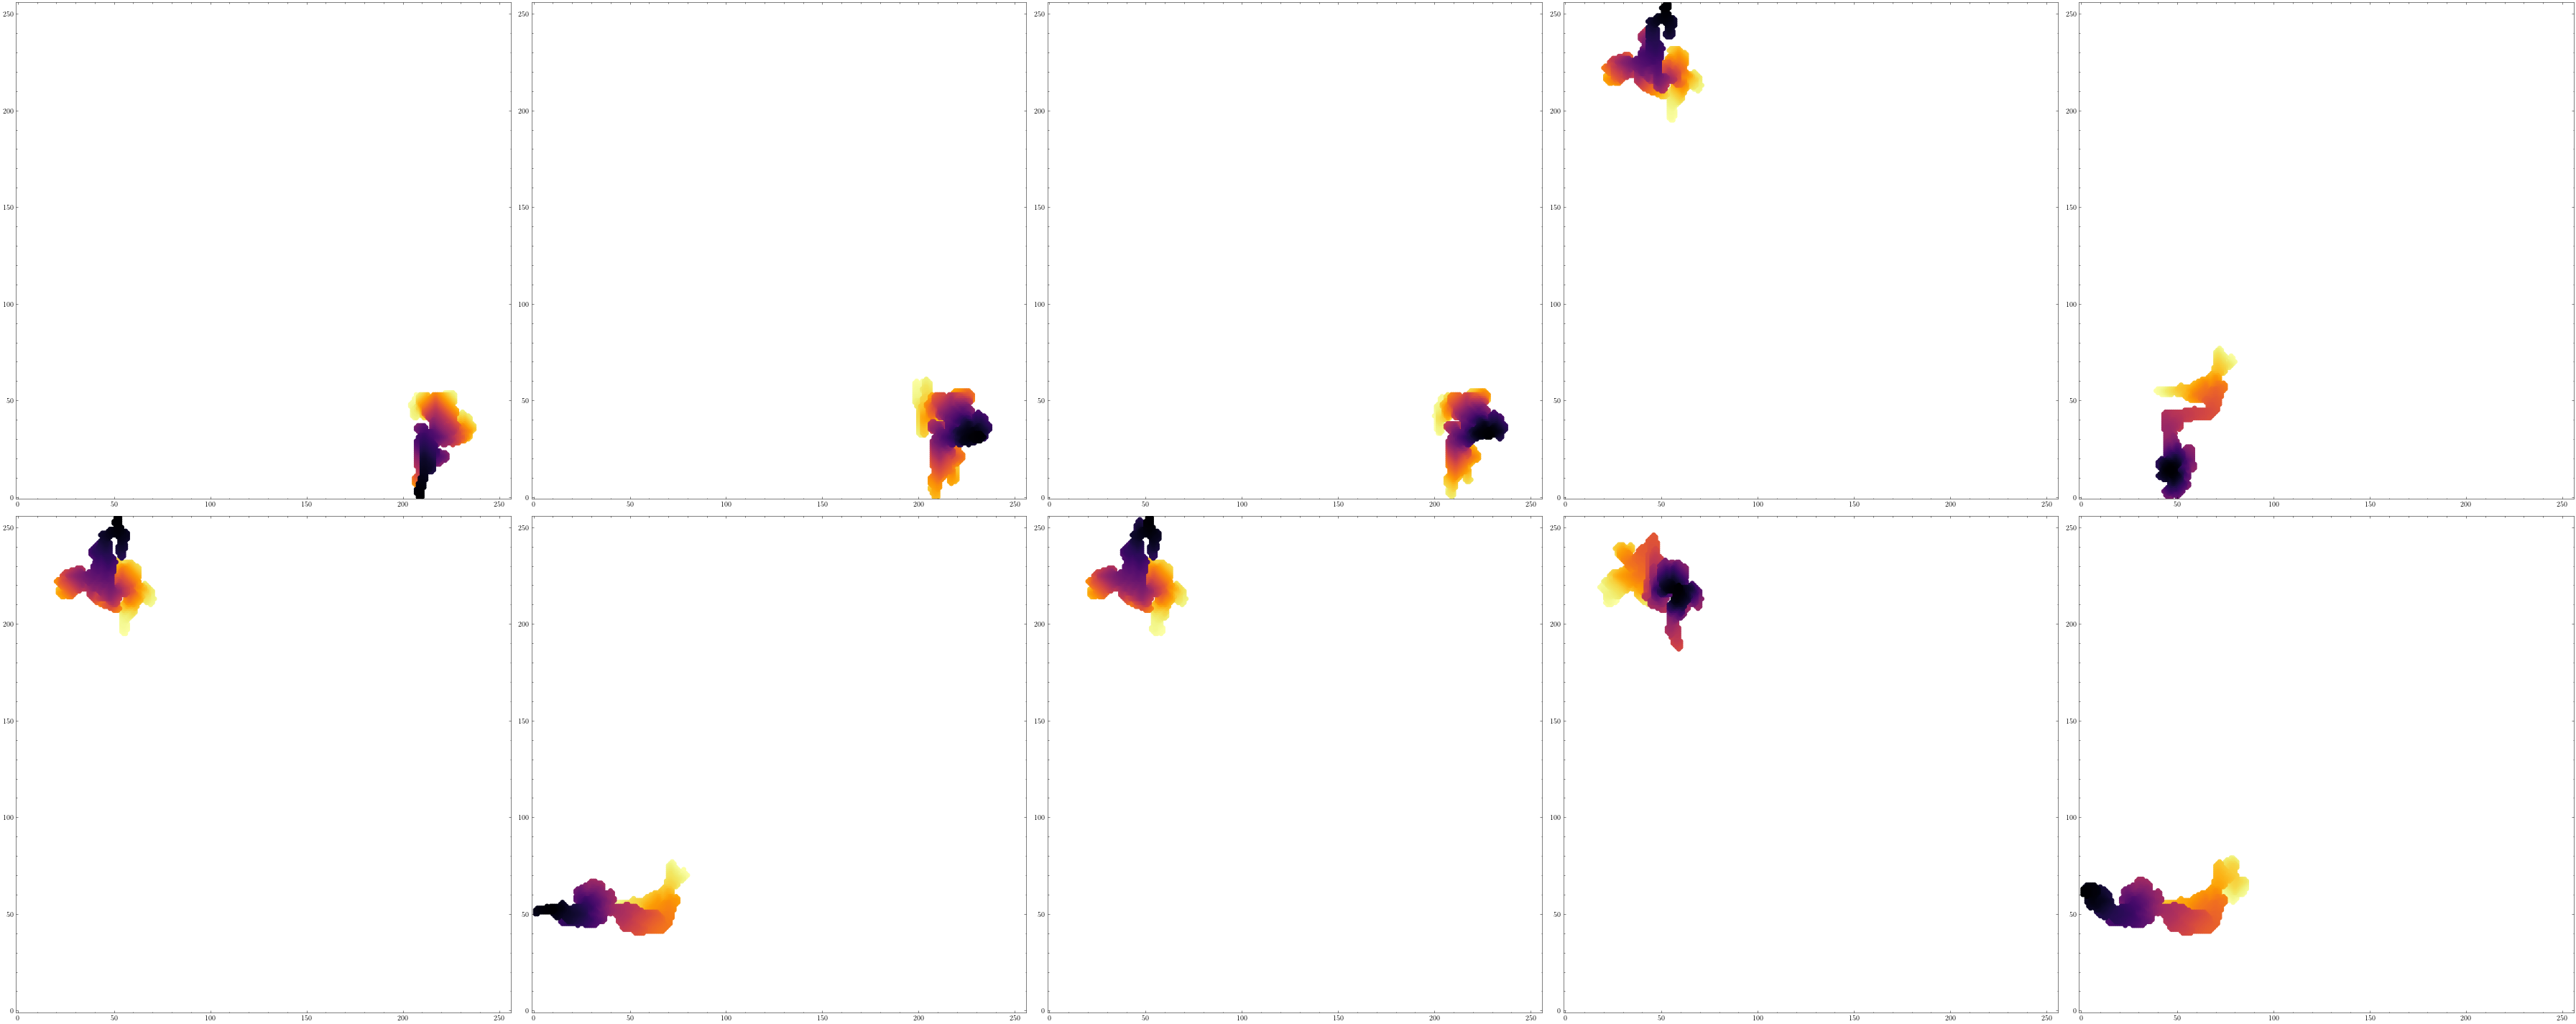

In [9]:
nbmaxline = 10
folder = "/data1/DATA_Duplat/Brut/PDF/PD5n14"
data = np.zeros((nbmaxline, (L1*L2)), dtype = int)
x, y = np.zeros_like(data), np.zeros_like(data)

fig, axis = plt.subplots(2,5,figsize = (50,20))
with open("{}/shape_outputB10.txt".format(folder), "r") as f:
        l = 0
        for line in f:
            if line.startswith("#"): 
                continue
            line_np = np.array(list(map(int, line.strip().split()[3:])), dtype = int)
            
            if len(line_np) >= ((L1 * L2)/100):
                data[l, :len(line_np)] = line_np
                l += 1
                
                if l == nbmaxline:
                    break
        
        for i, line in enumerate(data):
            x[i], y[i] = np.unravel_index(line, (L1, L2))
            mask = x[i]!=0
            f_x = np.array(x[i])[mask]
            f_y = np.array(y[i])[mask]
            
            NCURVES = len(f_x)
            colors = plt.cm.get_cmap('inferno')(1 - np.linspace(0, 1, NCURVES))
            k,l = np.unravel_index(i, (2,5))
            axis[k][l].scatter(f_x, f_y, c = colors)
            axis[k][l].set_xlim(-1,L1)
            axis[k][l].set_ylim(-1,L2)
            # axis[k][l].scatter(x[i], y[i], c= colors, s = 1)
            

plt.tight_layout()
plt.savefig("Avalanche_propagation.pdf")
plt.show()
            
        

#   Fractal distribution as function of the size

[40377     0     0   109   325   710    31    11  2148     0     0   228
     0     0  4703     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0]
[19037     0     2     0    12    12    55   119    16   158   823     1
   348     0     0   685     0   863     0     0    10     0     0     0
     0  3583     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0 

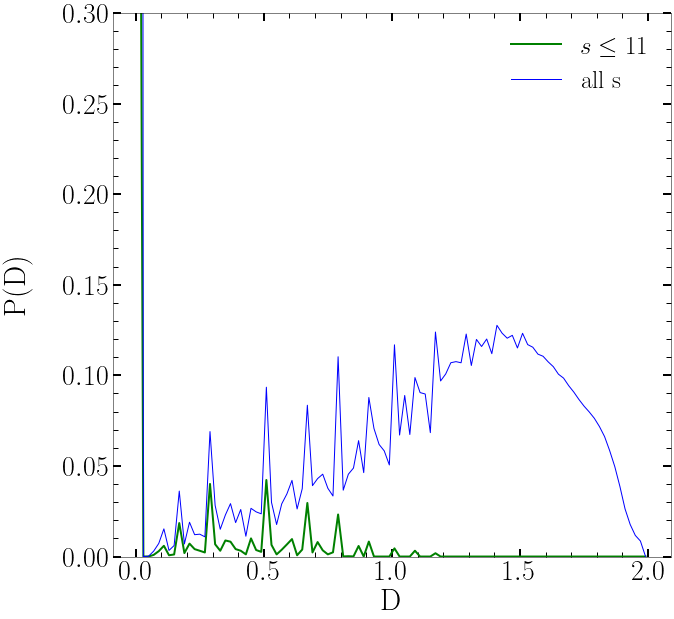

In [43]:
nbmaxline = 1e7

csize = 1e7
folder = Tfolderpath[-1]
nbline = 0
nmax_filtered = 0
fractalbox = 0
fractabox_filtered = 0
fractabox_filtered_diff0 = 0
slope = 0
s = 0
s_filtered = 0
nmax = 0

histo = np.zeros(100)
sumhisto = np.zeros(100)
bins = np.linspace(0,2,101)
bins_centers = (bins[1:] + bins[:-1])/2

NCURVES = 8
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

for chunk, chunk2 in zip(chunked_file_reader(f'{folder}/fractalbox.gz', chunksize=csize), 
                        chunked_file_reader(f'{folder}/Avalanche_outputB.gz', chunksize=csize, usecols=[6])):
        
    nbline += len(chunk2)
    fractalbox = np.array(chunk.iloc[:, :-1])
    s = np.array(chunk.iloc[:, 0])
    nmax = np.array(chunk.iloc[:, -1])
    slope = np.array(-chunk2.iloc[:,0])
    
    fig, ax = plt.subplots(figsize = (10,10))
    with open("fractal.txt", 'w') as f:
        for i in range(3,11):
            mask = s == i
            slope_f = slope[mask]
            Dmax = np.max(slope_f)
            fractalbox_f = fractalbox[mask]
            fractalbox_f2 = fractalbox_f[slope_f == Dmax]
            
            histo = np.histogram(slope_f, bins = bins)[0]
            sumhisto += histo
            f.write('{}: {}\n'.format(i, Dmax))
            for line in fractalbox_f2:
                f.write('{}\n'.format(line))
            f.write('\n')
            print(histo)
            
            mask2 = histo !=0
            filtered_histo = histo[mask2]
            #ax.plot(bins_centers, histo/sum(histo), color = colors[i-3], lw = 2 ,label = i)
            # print(Dmax)
            # print(fractalbox_f2)
        
        mask3 = sumhisto !=0
        filtered_sumhisto = sumhisto[mask3]
        ax.plot(bins_centers, sumhisto/sum(sumhisto), color = 'g', lw = 2 ,label = r"$s \leq 11$")  
            
    ax.set_ylim(0,0.3)
    
    if nbline >= nbmaxline : break

data = np.loadtxt("/data1/DATA_Duplat/Brut/Fractal/Fr1n1/stat_histofractal.txt")

mask4 = data != 0
filtered_data = data[0:]
ax.plot(bins_centers[0:], filtered_data*10/np.sum(filtered_data), color = 'b', label = 'all s')

para_fig(ax, 'D', 'P(D)')
plt.legend(fontsize = 25)

plt.show()